## Unblinded: Comparison & tension to Planck

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from getdist import plots, MCSamples
import sys
sys.path.append('../python')
import utils
%matplotlib inline

In [3]:
# DES Y3 unblind
blind = False
desy3_2pt = utils.read_cosmosis_mcmc_des_chain(
    '../output/unblind-metacal-796sims-february-Percival-2ptfix/des-y3-2pt-unblind-metacal-simcov.txt', to_mcsamples=True, blind=blind)
desy3_23pt= utils.read_cosmosis_mcmc_des_chain(
    '../output/unblind-metacal-796sims-february-Percival-2ptfix-3pcfsc/des-y3-2pt-map3-all-unblind-metacal.txt', to_mcsamples=True, blind=blind)
desy3_3pt = utils.read_cosmosis_mcmc_des_chain(
    '../output/unblind-metacal-796sims-february-Percival-2ptfix-3pcfsc/des-y3-map3-all-unblind-metacal.txt', to_mcsamples=True, blind=blind)


Removed no burn in
Removed no burn in
Removed no burn in


In [4]:
# Planck 2018
planck = utils.load_TTTEEElowE()

Removed no burn in


### Use Tensiometer
https://tensiometer.readthedocs.io/en/latest/example_non_gaussian_tension.html

In [5]:
sys.path.append('../../tensiometer')
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1" # Needed for tensiometer NF estimate

# import the tensiometer tools that we need:
import tensiometer
from tensiometer.utilities import stats_utilities as utilities
from tensiometer import mcmc_tension

In [6]:
diff_chain = mcmc_tension.parameter_diff_chain(desy3_23pt, planck, boost=4)

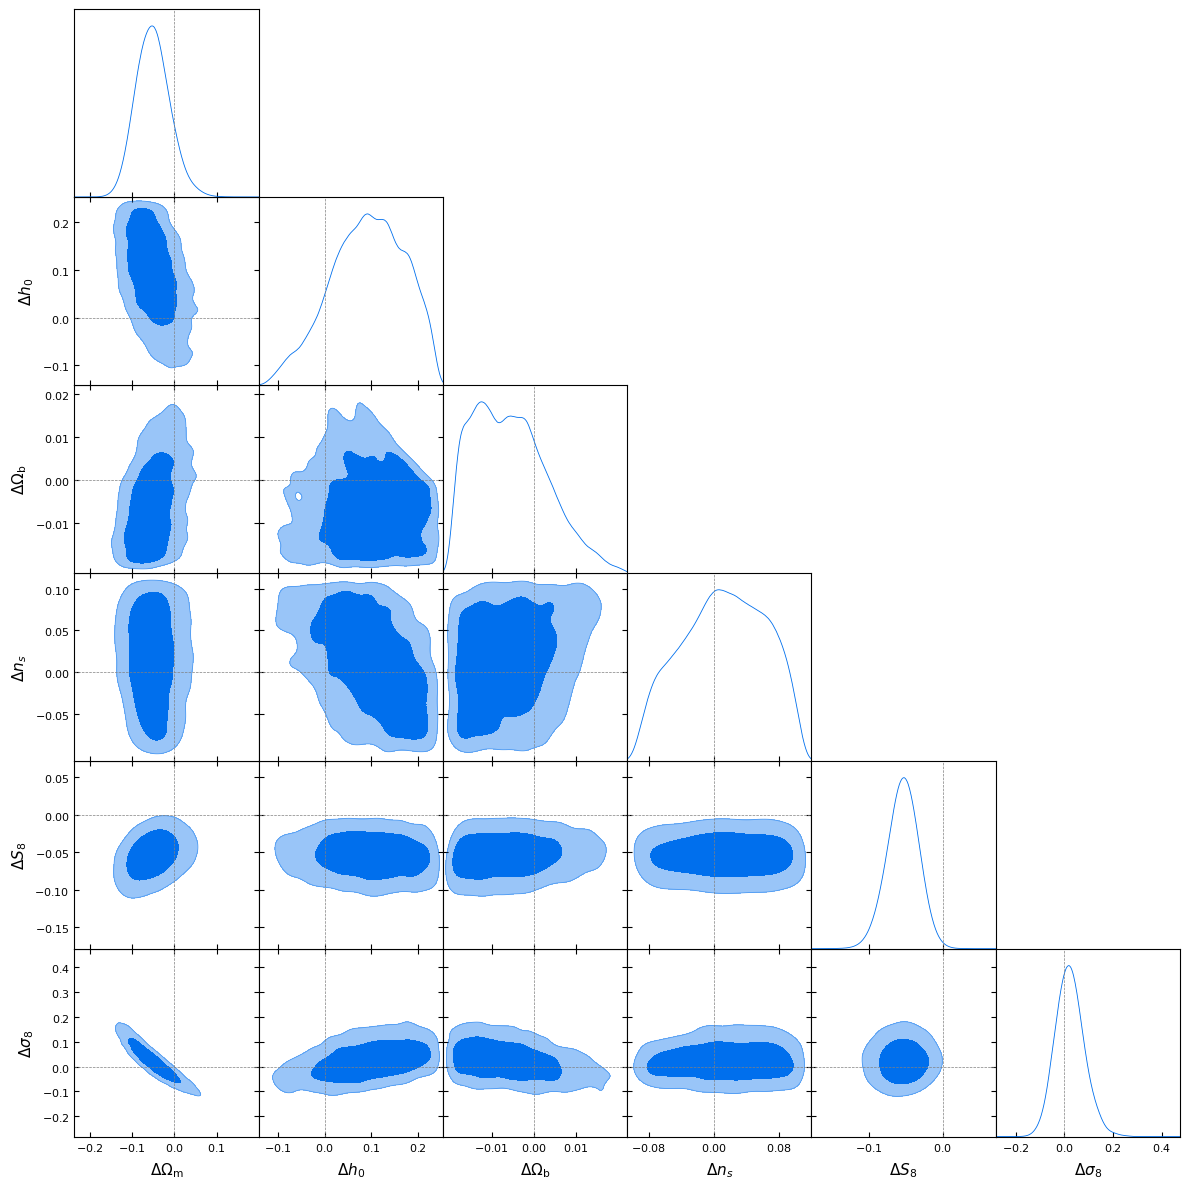

In [7]:
param_names = diff_chain.getParamNames().getRunningNames()
g = plots.get_subplot_plotter()
g.triangle_plot([diff_chain], params=param_names, 
                filled=True, markers={_p:0 for _p in param_names})
plt.show()

In [8]:
param_names

['delta_om', 'delta_h0', 'delta_ob', 'delta_ns', 'delta_s8', 'delta_sig8']

### KDE estimate
Below we keep the comments of the example notebook of the tensiometer for refernece.

> We first run the KDE algorithm with default settings and high feedback to have a sense of its inner workings:

In [9]:
shift_P, shift_low, shift_hi = mcmc_tension.kde_parameter_shift(diff_chain, feedback=10)

# print the results:
print(f'Shift probability considering all parameters:\n',
      f'   P = {shift_P:.5f} +{shift_hi-shift_P:.5f} -{shift_P-shift_low:.5f}')
# turn the result to effective number of sigmas:
print(f'    n_sigma = {utilities.from_confidence_to_sigma(shift_P):.3f}',
      f'+{utilities.from_confidence_to_sigma(shift_hi)-utilities.from_confidence_to_sigma(shift_P):.3f}',
      f'-{utilities.from_confidence_to_sigma(shift_P)-utilities.from_confidence_to_sigma(shift_low):.3f}')

Dimension       : 6
N    samples    : 36
Neff samples    : 33780.51
Smoothing scale : [0.118 0.118 0.118 0.118 0.118 0.118]
Building KD-Tree with leafsize = 400
Neighbours elimination
neighbor_elimination: chunk 1
    surviving elements 25229 of 97746
neighbor_elimination: chunk 2
    surviving elements 24131 of 97746
neighbor_elimination: chunk 3
    surviving elements 23853 of 97746
neighbor_elimination: chunk 4
    surviving elements 23736 of 97746
neighbor_elimination: chunk 5
    surviving elements 23682 of 97746
neighbor_elimination: chunk 6
    surviving elements 23658 of 97746
neighbor_elimination: chunk 7
    surviving elements 23635 of 97746
neighbor_elimination: chunk 8
    surviving elements 23624 of 97746
neighbor_elimination: chunk 9
    surviving elements 23618 of 97746
neighbor_elimination: chunk 10
    surviving elements 23612 of 97746
neighbor_elimination: chunk 11
    surviving elements 23608 of 97746
neighbor_elimination: chunk 12
    surviving elements 23608 of 977

100%|##########| 23604/23604 [01:39<00:00, 236.78it/s]


    surviving elements 23591 of 97746
KDE method: neighbor_elimination
Time taken for KDE calculation: 102.0 (s)
Shift probability considering all parameters:
    P = 0.98255 +0.01610 -0.05632
    n_sigma = 2.377 +0.829 -0.589


> As we can see the algorithm proceeds in two steps, elimination of points that are clearly above the probability of zero shift based on the probability estimate containing just a few nearest points and then brute force polishing of the leftover points. This gets the right answer and takes a fairly reasonable amount of time.
> 
> You could try to run this cell with method='brute_force' to see the type of performance improvement that this algorithm achieves.
> 
> One key parameter in the estimate of the KDE shift is the smoothing scale for the pdf. The default choice is the one that minimizes the mean integrated square error (MISE) under assumptions of Gaussianity.

In [11]:
shift_P, shift_low, shift_hi = mcmc_tension.kde_parameter_shift(diff_chain, scale='MISE', feedback=10)

# print the results:
print(f'Shift probability considering all parameters:\n',
      f'   P = {shift_P:.5f} +{shift_hi-shift_P:.5f} -{shift_P-shift_low:.5f}')
# turn the result to effective number of sigmas:
print(f'    n_sigma = {utilities.from_confidence_to_sigma(shift_P):.3f}',
      f'+{utilities.from_confidence_to_sigma(shift_hi)-utilities.from_confidence_to_sigma(shift_P):.3f}',
      f'-{utilities.from_confidence_to_sigma(shift_P)-utilities.from_confidence_to_sigma(shift_low):.3f}')

Dimension       : 6
N    samples    : 36
Neff samples    : 33780.51
Smoothing scale : [0.118 0.118 0.118 0.118 0.118 0.118]
Building KD-Tree with leafsize = 400
Neighbours elimination
neighbor_elimination: chunk 1
    surviving elements 25229 of 97746
neighbor_elimination: chunk 2
    surviving elements 24131 of 97746
neighbor_elimination: chunk 3
    surviving elements 23853 of 97746
neighbor_elimination: chunk 4
    surviving elements 23736 of 97746
neighbor_elimination: chunk 5
    surviving elements 23682 of 97746
neighbor_elimination: chunk 6
    surviving elements 23658 of 97746
neighbor_elimination: chunk 7
    surviving elements 23635 of 97746
neighbor_elimination: chunk 8
    surviving elements 23624 of 97746
neighbor_elimination: chunk 9
    surviving elements 23618 of 97746
neighbor_elimination: chunk 10
    surviving elements 23612 of 97746
neighbor_elimination: chunk 11
    surviving elements 23608 of 97746
neighbor_elimination: chunk 12
    surviving elements 23608 of 977

100%|##########| 23604/23604 [01:39<00:00, 238.14it/s]


    surviving elements 23591 of 97746
KDE method: neighbor_elimination
Time taken for KDE calculation: 101.2 (s)
Shift probability considering all parameters:
    P = 0.98255 +0.01610 -0.05632
    n_sigma = 2.377 +0.829 -0.589


> But we can try different choices. In particular we could try the asyntotic MISE estimator (AMISE):

In [12]:
shift_P, shift_low, shift_hi = mcmc_tension.kde_parameter_shift(diff_chain, scale='AMISE', feedback=10)

# print the results:
print(f'Shift probability considering all parameters:\n',
      f'   P = {shift_P:.5f} +{shift_hi-shift_P:.5f} -{shift_P-shift_low:.5f}')
# turn the result to effective number of sigmas:
print(f'    n_sigma = {utilities.from_confidence_to_sigma(shift_P):.3f}',
      f'+{utilities.from_confidence_to_sigma(shift_hi)-utilities.from_confidence_to_sigma(shift_P):.3f}',
      f'-{utilities.from_confidence_to_sigma(shift_P)-utilities.from_confidence_to_sigma(shift_low):.3f}')

Dimension       : 6
N    samples    : 36
Neff samples    : 33780.51
Smoothing scale : [0.108 0.108 0.108 0.108 0.108 0.108]
Building KD-Tree with leafsize = 400
Neighbours elimination
neighbor_elimination: chunk 1
    surviving elements 24092 of 97746
neighbor_elimination: chunk 2
    surviving elements 23285 of 97746
neighbor_elimination: chunk 3
    surviving elements 23085 of 97746
neighbor_elimination: chunk 4
    surviving elements 23013 of 97746
neighbor_elimination: chunk 5
    surviving elements 22987 of 97746
neighbor_elimination: chunk 6
    surviving elements 22969 of 97746
neighbor_elimination: chunk 7
    surviving elements 22956 of 97746
neighbor_elimination: chunk 8
    surviving elements 22945 of 97746
neighbor_elimination: chunk 9
    surviving elements 22942 of 97746
neighbor_elimination: chunk 10
    surviving elements 22937 of 97746
neighbor_elimination: polishing


100%|##########| 22937/22937 [01:31<00:00, 251.24it/s]


    surviving elements 22925 of 97746
KDE method: neighbor_elimination
Time taken for KDE calculation: 93.6 (s)
Shift probability considering all parameters:
    P = 0.98681 +0.01271 -0.05470
    n_sigma = 2.479 +1.012 -0.653


> which is slightly undersmoothing and hence resulting in a slightly higher tension.
> 
> Or we could try the maximum bandwidth that is (by design) oversmoothing:

In [13]:
shift_P, shift_low, shift_hi = mcmc_tension.kde_parameter_shift(diff_chain, scale='MAX', feedback=10)

# print the results:
print(f'Shift probability considering all parameters:\n',
      f'   P = {shift_P:.5f} +{shift_hi-shift_P:.5f} -{shift_P-shift_low:.5f}')
# turn the result to effective number of sigmas:
print(f'    n_sigma = {utilities.from_confidence_to_sigma(shift_P):.3f}',
      f'+{utilities.from_confidence_to_sigma(shift_hi)-utilities.from_confidence_to_sigma(shift_P):.3f}',
      f'-{utilities.from_confidence_to_sigma(shift_P)-utilities.from_confidence_to_sigma(shift_low):.3f}')

Dimension       : 6
N    samples    : 36
Neff samples    : 33780.51
Smoothing scale : [0.13 0.13 0.13 0.13 0.13 0.13]
Building KD-Tree with leafsize = 400
Neighbours elimination
neighbor_elimination: chunk 1
    surviving elements 26910 of 97746
neighbor_elimination: chunk 2
    surviving elements 25308 of 97746
neighbor_elimination: chunk 3
    surviving elements 24884 of 97746
neighbor_elimination: chunk 4
    surviving elements 24680 of 97746
neighbor_elimination: chunk 5
    surviving elements 24590 of 97746
neighbor_elimination: chunk 6
    surviving elements 24542 of 97746
neighbor_elimination: chunk 7
    surviving elements 24507 of 97746
neighbor_elimination: chunk 8
    surviving elements 24487 of 97746
neighbor_elimination: chunk 9
    surviving elements 24471 of 97746
neighbor_elimination: chunk 10
    surviving elements 24458 of 97746
neighbor_elimination: chunk 11
    surviving elements 24448 of 97746
neighbor_elimination: chunk 12
    surviving elements 24441 of 97746
nei

100%|##########| 24423/24423 [01:32<00:00, 263.06it/s]


    surviving elements 24410 of 97746
KDE method: neighbor_elimination
Time taken for KDE calculation: 95.8 (s)
Shift probability considering all parameters:
    P = 0.97583 +0.02067 -0.05867
    n_sigma = 2.254 +0.666 -0.520


> As we can see the MISE smoothing scale achieves a balance between these two. Overestimating the smoothing scale usually results in slightly smaller tensions.
> 
> We can now try the adaptive bandwidth:

In [14]:
shift_P, shift_low, shift_hi = mcmc_tension.kde_parameter_shift(diff_chain, scale='BALL', feedback=10)

# print the results:
print(f'Shift probability considering all parameters:\n',
      f'   P = {shift_P:.5f} +{shift_hi-shift_P:.5f} -{shift_P-shift_low:.5f}')
# turn the result to effective number of sigmas:
print(f'    n_sigma = {utilities.from_confidence_to_sigma(shift_P):.3f}',
      f'+{utilities.from_confidence_to_sigma(shift_hi)-utilities.from_confidence_to_sigma(shift_P):.3f}',
      f'-{utilities.from_confidence_to_sigma(shift_P)-utilities.from_confidence_to_sigma(shift_low):.3f}')

Dimension       : 6
N    samples    : 36
Neff samples    : 33780.51
BALL smoothing scale
Building KD-Tree with leafsize = 400
Neighbours elimination
neighbor_elimination: chunk 1
    surviving elements 17672 of 97746
neighbor_elimination: chunk 2
    surviving elements 17482 of 97746
neighbor_elimination: chunk 3
    surviving elements 17424 of 97746
neighbor_elimination: chunk 4
    surviving elements 17372 of 97746
neighbor_elimination: chunk 5
    surviving elements 17350 of 97746
neighbor_elimination: chunk 6
    surviving elements 17327 of 97746
neighbor_elimination: chunk 7
    surviving elements 17312 of 97746
neighbor_elimination: chunk 8
    surviving elements 17303 of 97746
neighbor_elimination: chunk 9
    surviving elements 17297 of 97746
neighbor_elimination: chunk 10
    surviving elements 17293 of 97746
neighbor_elimination: chunk 11
    surviving elements 17291 of 97746
neighbor_elimination: chunk 12
    surviving elements 17287 of 97746
neighbor_elimination: polishing


100%|##########| 17287/17287 [01:19<00:00, 216.36it/s]


    surviving elements 17268 of 97746
KDE method: neighbor_elimination
Time taken for KDE calculation: 81.9 (s)
Shift probability considering all parameters:
    P = 0.99040 +0.00949 -0.05324
    n_sigma = 2.590 +1.285 -0.730


> As we can see all results are mostly in agreement with each other and this provides an invaluable cross check of the different calculation techniques.
>
> The number of samples used in the calculation can be changed to make sure that everything is converged and makes sense. Since all algorithms work in a fairly straightforward way on a laptop we encourage to always try and compare different outputs to make sure the result is sensible.
> 
> We now verify that the calculation makes physical sense. We know that a difference between these two results mostly lives in a 2 dimensional parameter space so we can do the calculation there and plot the result.
> 
> In this case, since we are in two dimensions we can use the fft algorithm that is sensibly faster.

Time taken for 2D FFT-KDE calculation: 0.7 (s)
Shift probability considering all parameters:
    P = 0.95608 +0.03078 -0.06451
    n_sigma = 2.015 +0.465 -0.410


<Figure size 400x400 with 0 Axes>

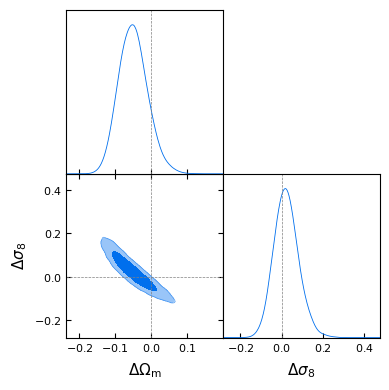

In [23]:
param_names = ['delta_om', 'delta_sig8']
shift_P, shift_low, shift_hi = mcmc_tension.kde_parameter_shift_2D_fft(diff_chain, param_names=param_names, feedback=10)

# print the results:
print(f'Shift probability considering all parameters:\n',
      f'   P = {shift_P:.5f} +{shift_hi-shift_P:.5f} -{shift_P-shift_low:.5f}')
# turn the result to effective number of sigmas:
print(f'    n_sigma = {utilities.from_confidence_to_sigma(shift_P):.3f}',
      f'+{utilities.from_confidence_to_sigma(shift_hi)-utilities.from_confidence_to_sigma(shift_P):.3f}',
      f'-{utilities.from_confidence_to_sigma(shift_P)-utilities.from_confidence_to_sigma(shift_low):.3f}')

# triangle plot with the 2D shift probability:
g = plots.get_single_plotter(ratio=1, width_inch=4)
diff_chain.updateSettings({'contours': [0.68, 0.95, shift_P]})
g.settings.num_plot_contours = 3
g.triangle_plot(diff_chain, param_names, filled=True, markers={name:0. for name in param_names});
plt.show()

Time taken for 2D FFT-KDE calculation: 1.1 (s)
Shift probability considering all parameters:
    P = 0.96474 +0.02679 -0.06212
    n_sigma = 2.105 +0.527 -0.448


<Figure size 400x400 with 0 Axes>

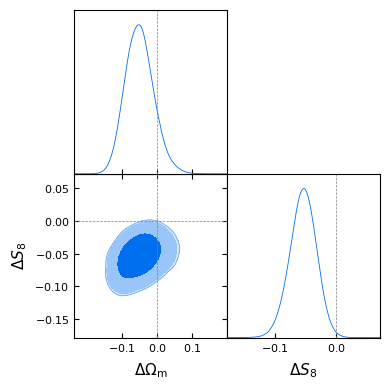

In [24]:
param_names = ['delta_om', 'delta_s8']
shift_P, shift_low, shift_hi = mcmc_tension.kde_parameter_shift_2D_fft(diff_chain, param_names=param_names, feedback=10)

# print the results:
print(f'Shift probability considering all parameters:\n',
      f'   P = {shift_P:.5f} +{shift_hi-shift_P:.5f} -{shift_P-shift_low:.5f}')
# turn the result to effective number of sigmas:
print(f'    n_sigma = {utilities.from_confidence_to_sigma(shift_P):.3f}',
      f'+{utilities.from_confidence_to_sigma(shift_hi)-utilities.from_confidence_to_sigma(shift_P):.3f}',
      f'-{utilities.from_confidence_to_sigma(shift_P)-utilities.from_confidence_to_sigma(shift_low):.3f}')

# triangle plot with the 2D shift probability:
g = plots.get_single_plotter(ratio=1, width_inch=4)
diff_chain.updateSettings({'contours': [0.68, 0.95, shift_P]})
g.settings.num_plot_contours = 3
g.triangle_plot(diff_chain, param_names, filled=True, markers={name:0. for name in param_names});
plt.show()

Okay, KDE already captures the tension, and all the optional choices agree each other.

## NF?
I did not run the Normalizing flow version.